## Exercises from Chapter 4: Implementing a GPT model from scratch to generate text

> **Attribution:** Portions of the code in this notebook follow and adapt the Apache-2.0-licensed implementation accompanying Sebastian Raschka's *Build a Large Language Model (From Scratch)*.  
> Original source code: https://github.com/rasbt/LLMs-from-scratch  
> Additional annotations, experiments, explanations, and study notes were created as part of my own learning and implementation process.

#### Adding the repository root to sys.path

In [1]:
# from pathlib import Path
# import sys

# # Current folder:
# # repository_root/chapter_04/exercises
# # i.e. 
# # import os  
# # print(os.getcwd()) 
# # Note: Python searches for chapter_03 (and all other needed imports) inside that folder and in the other locations listed in sys.path. but sys.path currently does not have the repo root
# # the snippet below adds the repo root to sys.path

# repo_root = Path.cwd().parents[1]

# if str(repo_root) not in sys.path:
#     sys.path.insert(0, str(repo_root))

# print("Repository root:", repo_root)

In [2]:
# sys.path # Now we can see the repo root listed in sys.path

### 4.1 Coding an LLM architecture

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # as used by the BPE tokenizer
    "context_length": 1024, # maximum sequence length (i.e. max num of tokens the model can handle via the positional embeddings)
    "emb_dim": 768,         # context vector embedding size
    "n_heads": 12,        # number of attention heads
    "n_layers": 12,       # number of transformer blocks in the model
    "drop_rate": 0.1,       # dropout rate (probability p)
    "qkv_bias": False       # Query-Key-Value bias
}

In [4]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"]) # token_embedding_layer Embedding(vocab_size, d_out)
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) # pos_embedding_layer: nn.Embedding(context_len, d_out)
        self.drop_emb = nn.Dropout(cfg["drop_rate"]) # Dropout layer with dropout rate p=drop_rate
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"]) #here, the normalized_shape = d_out = emb_dim
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"]) # The LM Head layer which will return logits

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx) # i.e. token_embeddings = tok_embedding_layer(inputs)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) # pos_embeddings
        x = tok_embeds + pos_embeds # x = input_embeddings
        x = self.drop_emb(x) # Dropout
        x = self.trf_blocks(x) # Encoder block
        x = self.final_norm(x) # Final Layer Norm
        logits = self.out_head(x) # LM Head returns logits (raw unnormalized outputs)
        return logits

class DummyTransformerBlock(nn.Module): # placeholder class and does nothing other than returning the input --> will later be replaced by the real 'TransformerBlock' class
    def __init__(self, cfg):
        super().__init__()        

    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module): # placeholder class and does nothing other than returning the input --> will later be replaced by the real 'LayerNorm' class
    def __init__(self, normalized_shape, eps=1e-5): # eps represents a very small positive number which prevents div by 0 (improves numerical stability)
        super().__init__()        

    def forward(self, x):
        return x

In [5]:
import torch
import tiktoken # open-source python library for the implementation of BPE algorithm

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every days holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1528, 6622,  257]])


In [6]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.0612,  0.1768, -0.8529,  ..., -0.9608, -0.1894, -0.4422],
         [ 0.2559,  0.6943, -0.1255,  ..., -0.7367,  1.2559,  0.5946],
         [ 0.8378,  1.4459, -0.1935,  ...,  1.4067, -0.1898,  0.6553],
         [ 0.3619,  1.7019, -0.7654,  ...,  1.0078,  0.1737, -0.5090]],

        [[-0.9291, -0.0768, -1.1879,  ..., -1.7291, -0.0162, -0.5473],
         [-0.8020,  0.5770,  0.2631,  ..., -1.2950, -0.1148, -0.2370],
         [ 0.8502,  1.3808, -0.3624,  ..., -0.6149,  0.0041, -0.1117],
         [ 0.8021, -0.6556,  0.5620,  ...,  1.9586, -0.1310,  0.3240]]],
       grad_fn=<ViewBackward0>)


### 4.2 Normalizing activations with layer normalization

In [7]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example) # the layer outputs are called activations presumably because a ReLU activation function has been applied to the layer?
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [8]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [9]:
out_norm = (out - mean)/torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [10]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [11]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim)) # Trainable Parameter that thhe LLM automatically adjusts during training 
        self.shift = nn.Parameter(torch.zeros(emb_dim)) # Trainable Parameter that thhe LLM automatically adjusts during training 

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean)/(torch.sqrt(var + self.eps)) # We add a small positive number to prevent division by 0
        return (self.scale * norm_x) + self.shift

In [12]:
print(out) # i.e. the output of the Sequential layer in the previous example

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [13]:
torch.set_printoptions(sci_mode=False)
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


### 4.3 Implementing a feed forward network with GELU activations

In [14]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x): # GELU(X) ~= 0.5*x*(1+ tanh[sqrt(2/pi) * (x + 0.044715*x^3)]))
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi)) * (x + 0.044715 * torch.pow(x,3))  ))

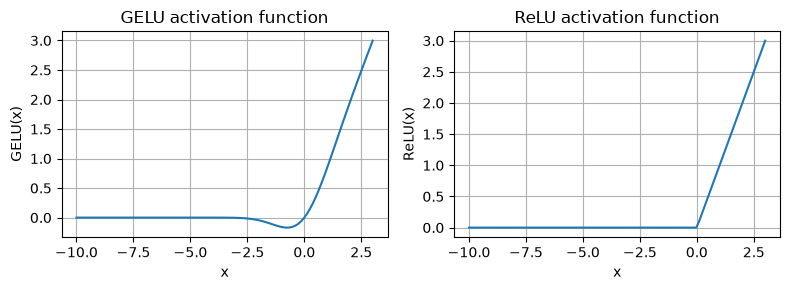

In [15]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-10, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

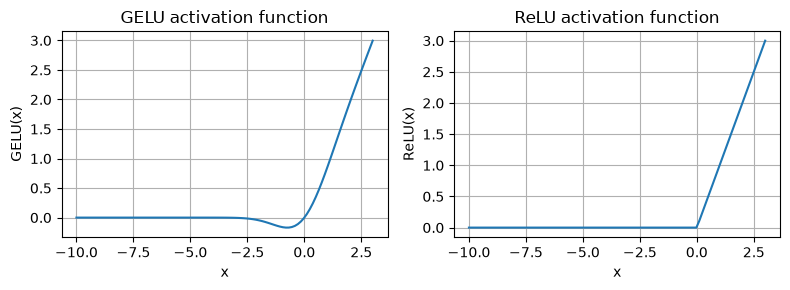

In [16]:
import matplotlib.pyplot as plt
gelu, relu = nn.GELU(), nn.ReLU()

x = torch.linspace(-10, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

In [18]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


### 4.4 Adding shortcut connections

In [19]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):        
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [20]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In [21]:
def print_gradients(model, x):
    output = model(x) # the predicted value
    target = torch.tensor([[0.]]) # The 'actual' value to compare against is 0
    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [22]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


We observe a vanishing gradient problem!

In [23]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896989583969116
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


The last layer (layers.4) still has a larger gradient than the other layers. However, the gradient value stabilizes as we progress toward the first layer (layers.0) and doesn’t shrink to a vanishingly small value.

NOTES:  
A shortcut connection does not skip the layer computation. It lets the original input bypass the layer and be added back to the layer’s output.

### 4.5 Connecting attention and linear layers in a transformer block

In [24]:
from chapter_03.scripts.attention import MultiHeadAttention
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"], 
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"], 
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"]) # Dropout to be applied after attn and ffn to regularize the model and prevent overfitting. Happens before the ADD (Residual)

    def forward(self, x):
        shortcut = x
        x = self.norm1(x) # pre-LayerNorm
        x = self.att(x) # Masked MHA
        x = self.drop_shortcut(x) # dropout before the ADD (Residual)
        x = x + shortcut # ADD (Residual) - Note that here x:layer_output and shortcut:initial value of x!

        shortcut = x
        x = self.norm2(x) # pre-LayerNorm
        x = self.ff(x) # FFN
        x = self.drop_shortcut(x) # dropout before the ADD (Residual)
        x = x + shortcut # ADD (Residual) - Note that here x:layer_output and shortcut:initial value of x!
        return x

In [25]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) # This simulates the input to the Transformer Block (Basically an input embeddings to which a dropout has been applied)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x) # The output of the Transformer Block

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


### 4.6 Coding the GPT model

In [26]:
class GPTModel(nn.Module): 
    def __init__(self, cfg): 
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])# tok_embedding_layer
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) # pos_embedding_layer
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])] # * unpacks the list comprehension - this represents the n_layers stacked Transformer Blocks
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # The LM Head which will output the logits (i.e. the raw unnormalized outputs)

    def forward(self, in_idx): # Takes in a batch of Input Token IDs
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx) # tok_embeddings
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) # pos_embeddings
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [27]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch) # where batch is a batch of Input Token IDs
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1528, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.8332, -0.2062,  0.2079,  ..., -0.6616,  0.5282, -0.7161],
         [ 1.1110,  0.9994, -0.0805,  ...,  0.5751,  0.2006, -0.5776],
         [-0.1215,  0.3992,  0.4241,  ...,  1.2515, -0.2092, -0.2805]]],
       grad_fn=<UnsafeViewBackward0>)


#### Calculating the total number of (trainable) parameters (in the model's parameter tensors)

In [28]:
total_params = sum(p.numel() for p in model.parameters())
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params:,}")
print(f"Total number of TRAINABLE parameters: {total_trainable_params:,}")

Total number of parameters: 163,009,536
Total number of TRAINABLE parameters: 163,009,536


#### # Test distinction between total_params and total_trainable_params

In [29]:
# Test distinction between total_params and total_trainable_params

# We FREEZE  one component of the model (for instance, we can freeze the Token Embedding Layer tok_emb):

for p in model.tok_emb.parameters():
    p.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params:,}")
print(f"Total number of TRAINABLE parameters: {total_trainable_params:,}")

Total number of parameters: 163,009,536
Total number of TRAINABLE parameters: 124,412,160


In [30]:
163059793 - 124462417


38597376

In [31]:
sum(p.numel() for p in model.tok_emb.parameters())

38597376

In [32]:
# Now UNFREEZING all parameters in the tok_emb layer:
for p in model.tok_emb.parameters():
    p.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params:,}")
print(f"Total number of TRAINABLE parameters: {total_trainable_params:,}")

Total number of parameters: 163,009,536
Total number of TRAINABLE parameters: 163,009,536


In [33]:
model.tok_emb.weight.shape

torch.Size([50257, 768])

In [34]:
model.out_head.weight.shape

torch.Size([50257, 768])

### Weight tying

**Weight tying means using the same weight matrix for two different jobs:**

1. **Input embedding:** Convert each token ID into an embedding vector.
2. **Output prediction:** Compare the final hidden vector against all vocabulary-token vectors to produce logits.

Without weight tying, the model has two separate large matrices:

```text
Token embedding matrix: [vocab_size, emb_dim]
Output-head matrix:      [vocab_size, emb_dim]
```

With weight tying, both layers share the same parameters:

```model.out_head.weight = model.tok_emb.weight```

In [35]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [36]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [37]:
outhead_params = sum(p.numel() for p in model.out_head.parameters())
outhead_params

38597376

In [38]:
total_params_gpt2 = total_params - outhead_params
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


Which corresponds to 124M parameters advertized by the GPT-2 model (which had used weight tying)

### Exercise 4.1 Number of parameters in feed forward and attention modules
Calculate and compare the number of parameters that are contained in the feed forward module and those that are contained in the multi-head attention module.

In [39]:
count_params_ff = 0
for trf_block in model.trf_blocks:
    for p in trf_block.ff.parameters():
        count_params_ff += p.numel()

count_params_mha = 0
for trf_block in model.trf_blocks:
    for p in trf_block.att.parameters():
        count_params_mha += p.numel()

print(f"Number of parameters in the FF Module: {count_params_ff:,}")
print(f"Number of parameters in the MHA Module: {count_params_mha:,}")

Number of parameters in the FF Module: 56,669,184
Number of parameters in the MHA Module: 28,320,768


In [40]:
# In one block:
print(f"ff: {count_params_ff/12}")
print(f"mha: {count_params_mha/12}")

ff: 4722432.0
mha: 2360064.0


In [41]:
# which corresponds to:
block = TransformerBlock(GPT_CONFIG_124M) # one transformer  block

singleblock_params_ff = sum(p.numel() for p in block.ff.parameters())
singleblock_params_mha = sum(p.numel() for p in block.att.parameters())
print(f"Number of parameters in the FF Module: {singleblock_params_ff:,}")
print(f"Number of parameters in the MHA Module: {singleblock_params_mha:,}")

Number of parameters in the FF Module: 4,722,432
Number of parameters in the MHA Module: 2,360,064


## Model Weight Memory requirements 

```
Model_Weights_Memory = P x bytes_per_param
```

Where:  
`P`: Parameters count  
`bytes_per_param`: number of bytes per parameter @ a particular precision (ex: @FP32, FP16, INT8, etc.) 

8 bits -> 1 byte   (--> bytes_per_param = 1  @INT8 precison)  
16 bits -> 2 bytes (--> bytes_per_param = 2  @FP16 precision)  
32 bits -> 4 bytes (--> bytes_per_param = 4  @FP32 precision)  

Now, for our GPT-2 small model, the parameter count = 163,009,536 (without weight tying).  
And so:

```text
Weight Memory = P x bytes_per_param = 163,009,536 x 4 (@FP32 precision)  
                                    = 652,038,144 bytes  
                                    ~ 621.83 MB  
```

(Note that in memory calculations, **1K ~ 1,024** --> and so: 652,038,144 bytes ~ 652,038,144/1024 KB = 636,756 KB ~ 636,756/1,024 MB = **621.83 MB**)  

**And to be more precise: 621.83 MiB**  

`1 MiB=1,048,576 bytes=1024^2 bytes` (`MiB` stands for **mebibyte**.)  

By contrast:  

`1 MB=1,000,000 bytes ` 

So:  

`MiB` uses binary units based on powers of 1024.  
`MB` uses decimal units based on powers of 1000.  

The binary counterpart of KB is `KiB`, which stands for **kibibyte**.  
```text
1 KB = 1,000 bytes
1 KiB = 1,024 bytes
```

### Exercise 4.2 Initializing larger GPT models
We initialized a 124-million-parameter GPT model, which is known as “GPT-2 small.” Without making any code modifications besides updating the configuration file, use the GPTModel class to implement:  
GPT-2 medium (using 1,024-dimensional embeddings, 24 transformer blocks, 16 multi-head attention heads),  
GPT-2 large (1,280-dimensional embeddings, 36 transformer blocks, 20 multi-head attention heads), and  
GPT-2 XL (1,600-dimensional embeddings, 48 transformer blocks, 25 multi-head attention heads).  
As a bonus, calculate the total number of parameters in each GPT model.

In [42]:
cfg_gpt_medium = GPT_CONFIG_124M.copy()
cfg_gpt_medium["emb_dim"] = 1024
cfg_gpt_medium["n_layers"] = 24
cfg_gpt_medium["n_heads"] = 16

cfg_gpt_large = GPT_CONFIG_124M.copy()
cfg_gpt_large["emb_dim"] = 1280
cfg_gpt_large["n_layers"] = 36
cfg_gpt_large["n_heads"] = 20

cfg_gpt_XL = GPT_CONFIG_124M.copy()
cfg_gpt_XL["emb_dim"] = 1600
cfg_gpt_XL["n_layers"] = 48
cfg_gpt_XL["n_heads"] = 25

In [43]:
model_medium = GPTModel(cfg_gpt_medium)
model_large = GPTModel(cfg_gpt_large)
model_xl = GPTModel(cfg_gpt_XL)

# model dictionary variable where key is the model name, and value is the actual GPT-2 model version
models_dic = {"GPT2-Small": model, "GPT2-Medium": model_medium, "GPT2-Large": model_large, "GPT2-XL": model_xl}

# dictionary where key is the precision and value is the corresponding bytes_per_param
bytes_at_precision_dic = {"FP32": 4, "FP16":2, "INT8": 1}

for name, m in models_dic.items():
    total_params = sum(p.numel() for p in m.parameters()) # WITHOUT weight tying
    params_out_head = sum(p.numel() for p in m.out_head.parameters()) # duplicated number of params
    total_params_with_weight_tying = total_params - params_out_head # WITH weight tying
    print(f"**************************\n{name} Model:\n")
    print(f"Number of parameters WITHOUT weight tying: {total_params:,}")
    print(f"Number of parameters WITH weight tying: {total_params_with_weight_tying:,}")    
    for prec, bytes_per_param in bytes_at_precision_dic.items():
        weight_memory = total_params * bytes_per_param # result in bytes
        weight_memory = weight_memory/(1024**2) # result in MB
        weight_memory_with_weight_tying = total_params_with_weight_tying * bytes_per_param # result in bytes
        weight_memory_with_weight_tying = weight_memory_with_weight_tying/(1024**2) # result in MB
        print(f"------\n@{prec} precision:\n")
        print(f"Weight Memory Size: {weight_memory:.2f} MB  (WITHOUT weight tying)")
        print(f"Weight Memory Size: {weight_memory_with_weight_tying:.2f} MB (WITH weight tying)")


**************************
GPT2-Small Model:

Number of parameters WITHOUT weight tying: 163,009,536
Number of parameters WITH weight tying: 124,412,160
------
@FP32 precision:

Weight Memory Size: 621.83 MB  (WITHOUT weight tying)
Weight Memory Size: 474.59 MB (WITH weight tying)
------
@FP16 precision:

Weight Memory Size: 310.92 MB  (WITHOUT weight tying)
Weight Memory Size: 237.30 MB (WITH weight tying)
------
@INT8 precision:

Weight Memory Size: 155.46 MB  (WITHOUT weight tying)
Weight Memory Size: 118.65 MB (WITH weight tying)
**************************
GPT2-Medium Model:

Number of parameters WITHOUT weight tying: 406,212,608
Number of parameters WITH weight tying: 354,749,440
------
@FP32 precision:

Weight Memory Size: 1549.58 MB  (WITHOUT weight tying)
Weight Memory Size: 1353.26 MB (WITH weight tying)
------
@FP16 precision:

Weight Memory Size: 774.79 MB  (WITHOUT weight tying)
Weight Memory Size: 676.63 MB (WITH weight tying)
------
@INT8 precision:

Weight Memory Size: 3

### 4.7 Generating text

In [44]:
def generate_text_simple(model, idx, max_new_tokens, context_size): # idx is batch of list of token IDs and has shape (b, curr_seq_len)
    for _ in range(max_new_tokens): # we establish the nbr of iterations (up to max_num_tokens)
        idx_cond = idx[:, -context_size:] # Keep only the most recent tokens that fit in the context window - shape: (b, min(curr_seq_len, context_size)) - idx conditioned context
        with torch.no_grad(): # we do not track gradients
            logits = model(idx_cond) # shape: (b, seq_len, vocab_size)
        logits = logits[:, -1, :] # we only care about embedding for the last token in the sequence --> shape: (b, 1, vocab_size) i.e. ~(b, vocab_size)
        probas = torch.softmax(logits, dim=-1) # shape remains: (batch_size, vocab_size)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True) # shape: (b, 1)
        idx = torch.cat((idx, idx_next), dim=1) # Append the predicted token to each sequence --> shape: (b, curr_seq_len+1) 
    return idx

In [45]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [46]:
model.eval() # .eval mode disables random components like dropout which are only used during training (here we are trying to do Inference (i.e. use the model to generate text)!!!)
out  = generate_text_simple(
    model=model,
    idx = encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [47]:
decode_text = tokenizer.decode(out.squeeze(0).tolist())
print(decode_text)

Hello, I am Featureiman Byeswickattribute argue


As we can see, the model generated gibberish rather than coherent text such as *“Hello, I am a model ready to help.”*  This happens because **we haven’t trained the model yet** (Model training is a large topic in itself, and we will tackle it in the next chapter.).

Also note that GPT-2’s BPE tokenizer is a **subword tokenizer**. The model did in fact generate six new tokens, but tokens do not necessarily correspond to complete words. Several subword tokens may combine into a single visible word.

In general:

```text
number of generated tokens ≠ number of generated words
```

### Exercise 4.3 Using separate dropout parameters
At the beginning of this chapter, we defined a global drop_rate setting in the GPT_ CONFIG_124M dictionary to set the dropout rate in various places throughout the GPTModel architecture. Change the code to specify a separate dropout value for the various dropout layers throughout the model architecture. (Hint: there are three distinct places where we used dropout layers: the embedding layer, shortcut layer, and multi-head attention module.)

In [48]:
GPT_CONFIG_124M_extended = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate_emb": 0.1,
    "drop_rate_att": 0.1,
    "drop_rate_shortcut": 0.1,
    "qkv_bias": False
}

In [49]:
class GPTModel(nn.Module): # This version uses the cfg: GPT_CONFIG_124M_extended
    def __init__(self, cfg): 
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])# tok_embedding_layer
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) # pos_embedding_layer
        self.drop_emb = nn.Dropout(cfg["drop_rate_emb"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])] # * unpacks the list comprehension - this represents the n_layers stacked Transformer Blocks
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # The LM Head which will output the logits (i.e. the raw unnormalized outputs)

    def forward(self, in_idx): # Takes in a batch of Input Token IDs
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx) # tok_embeddings
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) # pos_embeddings
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

from chapter_03.scripts.attention import MultiHeadAttention
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"], 
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"], 
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate_att"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate_shortcut"]) # Dropout to be applied after attn and ffn to regularize the model and prevent overfitting. Happens before the ADD (Residual)

    def forward(self, x):
        shortcut = x
        x = self.norm1(x) # pre-LayerNorm
        x = self.att(x) # Masked MHA
        x = self.drop_shortcut(x) # dropout before the ADD (Residual)
        x = x + shortcut # ADD (Residual) - Note that here x:layer_output and shortcut:initial value of x!

        shortcut = x
        x = self.norm2(x) # pre-LayerNorm
        x = self.ff(x) # FFN
        x = self.drop_shortcut(x) # dropout before the ADD (Residual)
        x = x + shortcut # ADD (Residual) - Note that here x:layer_output and shortcut:initial value of x!
        return x

In [51]:
model = GPTModel(GPT_CONFIG_124M_extended)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total Params: {total_params:,}")

Total Params: 163,009,536
